In [142]:
import os, pickle

from physics.simulation import mcfm, msq
from physics.hzz import zpair, zz4l
from datasets import balanced
from models import carl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import hist

import torch
from torch.utils.data import Dataset
from lightning import Trainer

In [143]:
OUTPUT_DIR = '../jobs/carl/refactor-two-leptons'
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '../..'

EPOCH = '05'
VAL_LOSS = 0.69
VERSION = 0

CHECKPOINT = f'checkpoint-carl-epoch={EPOCH}-val_loss={VAL_LOSS}.ckpt'
LIGHTNING_DIR = f'lightning_logs/version_{VERSION}'

#CHECKPOINT = f'checkpoint-carl-train-epoch=199-train_loss=0.03.ckpt'

COMPONENT_NUMERATOR = msq.Component.SBI
COMPONENT_DENOMINATOR = msq.Component.BKG

COMPONENT_FILE_N = msq.Component.SBI
COMPONENT_FILE_D = msq.Component.BKG

SAMPLE_SIZE = 10000


FEATURES=['l1_px', 'l1_py', 'l1_pz', 'l1_E', 
          'l2_px', 'l2_py', 'l2_pz', 'l2_E', 
          'l3_px', 'l3_py', 'l3_pz', 'l3_E', 
          'l4_px', 'l4_py', 'l4_pz', 'l4_E']

#FEATURES=['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z1_pt', 'Z2_mass', 'Z2_pt', '4l_mass', '4l_energy', '4l_rapidity']

BATCH_SIZE = 256
SEED = 42

In [144]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

comp_strings = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.BKG : 'BKG',
    msq.Component.INT : 'INT'
}

In [145]:
events_numerator = mcfm.from_csv(cross_section=xs[COMPONENT_NUMERATOR], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_FILE_N]), n_rows=int(SAMPLE_SIZE*1.2)).reweight(COMPONENT_FILE_N, COMPONENT_NUMERATOR)
events_denominator = mcfm.from_csv(cross_section=xs[COMPONENT_DENOMINATOR], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_FILE_D]), n_rows=int(SAMPLE_SIZE*1.2)).reweight(COMPONENT_FILE_D, COMPONENT_DENOMINATOR)

z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()

events_numerator = events_numerator.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]
events_denominator = events_denominator.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]

0.0643227034393
0.06701000323442


In [146]:
class BalancedDataset(Dataset):
    def __init__(self, events_sig, events_bkg, component_sig, component_bkg, features, sample_size, random_state=None):
        super().__init__()

        unweighted_sig_indices = events_sig.weights.sample(n=sample_size, replace=True, weights=events_sig.weights, random_state=random_state).index
        events_sig_unweighted = mcfm.Process(
            events_sig.kinematics.loc[unweighted_sig_indices].reset_index(drop=True),
            events_sig.components.loc[unweighted_sig_indices].reset_index(drop=True),
            pd.Series(np.ones_like(unweighted_sig_indices)).reset_index(drop=True)
        )
        targets_sig = (events_sig.probabilities/(events_sig.probabilities + events_sig.reweight(component_sig, component_bkg).probabilities)).loc[unweighted_sig_indices].reset_index(drop=True)

        unweighted_bkg_indices = events_bkg.weights.sample(n=sample_size, replace=True, weights=events_bkg.weights, random_state=random_state).index
        events_bkg_unweighted = mcfm.Process(
            events_bkg.kinematics.loc[unweighted_bkg_indices].reset_index(drop=True),
            events_bkg.components.loc[unweighted_bkg_indices].reset_index(drop=True),
            pd.Series(np.ones_like(unweighted_bkg_indices)).reset_index(drop=True)
        )
        targets_bkg = (events_bkg.reweight(component_bkg, component_sig).probabilities/(events_bkg.reweight(component_bkg, component_sig).probabilities + events_bkg.probabilities)).loc[unweighted_bkg_indices].reset_index(drop=True)

        # Get only required features
        X_sig = events_sig_unweighted.kinematics[features].to_numpy()
        X_bkg = events_bkg_unweighted.kinematics[features].to_numpy()

        self.X = np.concatenate([X_sig, X_bkg])

        self.s = np.concatenate([targets_sig, targets_bkg])

        self.X, self.s = shuffle(self.X, self.s, random_state=random_state)
    
    def __len__(self):
        return len(self.s)

    def __getitem__(self, index):
        return torch.tensor(self.X[index], dtype=torch.float32), torch.tensor(self.s[index], dtype=torch.float32)

In [147]:
events_num_train, events_num_val = events_numerator.shuffle(random_state=SEED).split(train_size=0.5, val_size=0.5)
events_den_train, events_den_val = events_denominator.shuffle(random_state=SEED).split(train_size=0.5, val_size=0.5)

training_data = BalancedDataset(events_num_train, events_den_train, COMPONENT_NUMERATOR, COMPONENT_DENOMINATOR, FEATURES, SAMPLE_SIZE, SEED)
validation_data = BalancedDataset(events_num_val, events_den_val, COMPONENT_NUMERATOR, COMPONENT_DENOMINATOR, FEATURES, SAMPLE_SIZE, SEED)

if SCALER_FILE is not None:
    with open(os.path.join(OUTPUT_DIR, SCALER_FILE), 'rb') as f:
        scaler_X = pickle.load(f)
    
    training_data.X = scaler_X.transform(training_data.X)
    validation_data.X = scaler_X.transform(validation_data.X)

In [148]:
loaded_model = carl.CARL.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

In [149]:
predictions_train = loaded_model(torch.tensor(training_data.X, dtype=torch.float32)).detach().view(-1).numpy()
targets_train = training_data.s

In [150]:
predictions_val = loaded_model(torch.tensor(validation_data.X, dtype=torch.float32)).detach().view(-1).numpy()
targets_val = validation_data.s

In [151]:
targets_train=training_data.s
targets_val=validation_data.s

In [152]:
ratios_train_pred = predictions_train/(1-predictions_train)
ratios_train_target = targets_train/(1-targets_train)

ratios_val_pred = predictions_val/(1-predictions_val)
ratios_val_target = targets_val/(1-targets_val)

/tmp/ipykernel_1477075/1810295936.py:42: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(h_targets_train.axes[0].centers, h_targets_train.values()/h_targets_train.values(), yerr=np.sqrt(h_targets_train.variances())/h_targets_train.values(), color='royalblue', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
/tmp/ipykernel_1477075/1810295936.py:43: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(h_predictions_train.axes[0].centers, h_predictions_train.values()/h_targets_train.values(), yerr=np.sqrt((np.sqrt(h_predictions_train.variances())/h_targets_train.values())**2 + (- np.sqrt(h_targets_train.variances())*h_predictions_train.values()/h_targets_train.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'')
/tmp/ipykernel_1477075/1810295936.py:49: RuntimeWarning: invalid value encountered in divide
  ax4.errorbar(h_targets_val.axes[0].centers, h_targets_val.values()/h_targets_val.values(), yerr=np.sqrt(h_targets_val.varia

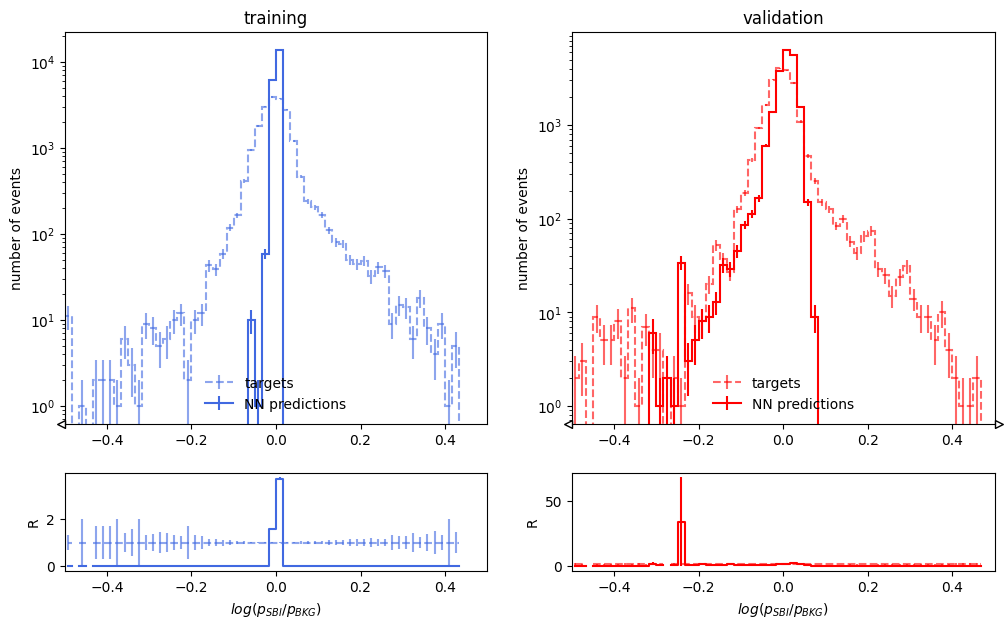

In [166]:
BINS = 60

bounds = [-0.5,0.5]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_predictions_train.fill(np.log(ratios_train_pred))

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_targets_train.fill(np.log(ratios_train_target))


h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_predictions_val.fill(np.log(ratios_val_pred)*10)

h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_targets_val.fill(np.log(ratios_val_target))

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, gridspec_kw={'height_ratios': [4, 1]}, figsize=(12,7))

h_targets_train.plot(ax=ax1, color='royalblue', linestyle='--', label='targets', alpha=0.6, yerr=np.sqrt(h_targets_train.variances()))
h_predictions_train.plot(ax=ax1, color='royalblue', linestyle='-', label='NN predictions', yerr=np.sqrt(h_predictions_train.variances()))

h_targets_val.plot(ax=ax2, color='red', linestyle='--', label='targets', alpha=0.6, yerr=np.sqrt(h_targets_val.variances()))
h_predictions_val.plot(ax=ax2, color='red', label='NN predictions', yerr=np.sqrt(h_predictions_val.variances()))

ax1.set_title('training')
ax1.set_xlabel('')
ax3.set_xlabel(f'$log(p_{{{comp_strings[COMPONENT_NUMERATOR]}}}/p_{{{comp_strings[COMPONENT_DENOMINATOR]}}})$')
ax1.set_ylabel('number of events')
ax1.set_yscale('log')
ax1.set_xlim(*bounds)
ax1.legend(loc='lower center', frameon=False)

ax2.set_title('validation')
ax2.set_xlabel('')
ax4.set_xlabel(f'$log(p_{{{comp_strings[COMPONENT_NUMERATOR]}}}/p_{{{comp_strings[COMPONENT_DENOMINATOR]}}})$')
ax2.set_ylabel('number of events')
ax2.set_yscale('log')
ax2.set_xlim(*bounds)
ax2.legend(loc='lower center', frameon=False)

ax3.errorbar(h_targets_train.axes[0].centers, h_targets_train.values()/h_targets_train.values(), yerr=np.sqrt(h_targets_train.variances())/h_targets_train.values(), color='royalblue', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
ax3.errorbar(h_predictions_train.axes[0].centers, h_predictions_train.values()/h_targets_train.values(), yerr=np.sqrt((np.sqrt(h_predictions_train.variances())/h_targets_train.values())**2 + (- np.sqrt(h_targets_train.variances())*h_predictions_train.values()/h_targets_train.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'')

#ax3.set_ylim(0,3)
ax3.set_ylabel('R')
ax3.set_xlim(*bounds)

ax4.errorbar(h_targets_val.axes[0].centers, h_targets_val.values()/h_targets_val.values(), yerr=np.sqrt(h_targets_val.variances())/h_targets_val.values(), color='red', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
ax4.errorbar(h_predictions_val.axes[0].centers, h_predictions_val.values()/h_targets_val.values(), yerr=np.sqrt((np.sqrt(h_predictions_val.variances())/h_targets_val.values())**2 + (- np.sqrt(h_targets_val.variances())*h_predictions_val.values()/h_targets_val.values()**2)**2), color='red', drawstyle='steps-mid', label=f'')

#ax4.set_ylim(0,3)
ax4.set_ylabel('R')
ax4.set_xlim(*bounds)

plt.show()

/tmp/ipykernel_1477075/906833300.py:42: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(h_targets_train.axes[0].centers, h_targets_train.values()/h_targets_train.values(), yerr=np.sqrt(h_targets_train.variances())/h_targets_train.values(), color='royalblue', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
/tmp/ipykernel_1477075/906833300.py:43: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(h_predictions_train.axes[0].centers, h_predictions_train.values()/h_targets_train.values(), yerr=np.sqrt((np.sqrt(h_predictions_train.variances())/h_targets_train.values())**2 + (- np.sqrt(h_targets_train.variances())*h_predictions_train.values()/h_targets_train.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'')
/tmp/ipykernel_1477075/906833300.py:48: RuntimeWarning: invalid value encountered in divide
  ax4.errorbar(h_targets_val.axes[0].centers, h_targets_val.values()/h_targets_val.values(), yerr=np.sqrt(h_targets_val.variance

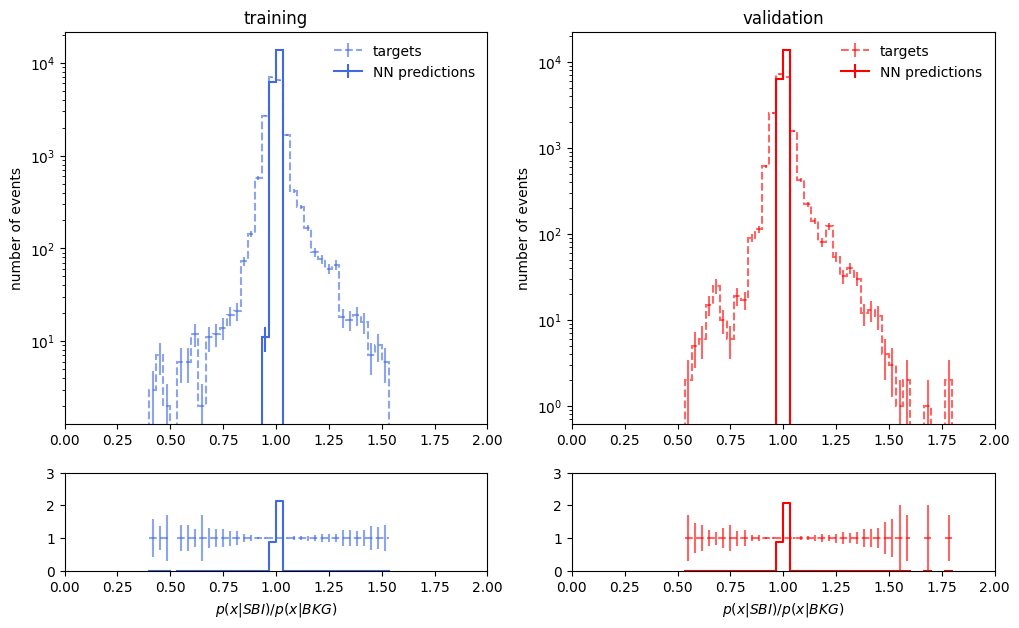

In [167]:
BINS = 60

bounds = [0,2]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_predictions_train.fill(ratios_train_pred)

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_targets_train.fill(ratios_train_target)


h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_predictions_val.fill(ratios_val_pred)

h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
h_targets_val.fill(ratios_val_target)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, gridspec_kw={'height_ratios': [4, 1]}, figsize=(12,7))

h_targets_train.plot(ax=ax1, color='royalblue', linestyle='--', label='targets', alpha=0.6, yerr=np.sqrt(h_targets_train.variances()))
h_predictions_train.plot(ax=ax1, color='royalblue', linestyle='-', label='NN predictions', yerr=np.sqrt(h_predictions_train.variances()))

h_targets_val.plot(ax=ax2, color='red', linestyle='--', label='targets', alpha=0.6, yerr=np.sqrt(h_targets_val.variances()))
h_predictions_val.plot(ax=ax2, color='red', label='NN predictions', yerr=np.sqrt(h_predictions_val.variances()))

ax1.set_title('training')
ax1.set_xlabel('')
ax3.set_xlabel(f'$p(x|{comp_strings[COMPONENT_NUMERATOR]})/p(x|{comp_strings[COMPONENT_DENOMINATOR]})$')
ax1.set_ylabel('number of events')
ax1.set_yscale('log')
ax1.set_xlim(*bounds)
ax1.legend(loc='upper right', frameon=False)

ax2.set_title('validation')
ax2.set_xlabel('')
ax4.set_xlabel(f'$p(x|{comp_strings[COMPONENT_NUMERATOR]})/p(x|{comp_strings[COMPONENT_DENOMINATOR]})$')
ax2.set_ylabel('number of events')
ax2.set_yscale('log')
ax2.set_xlim(*bounds)
ax2.legend(loc='upper right', frameon=False)

ax3.errorbar(h_targets_train.axes[0].centers, h_targets_train.values()/h_targets_train.values(), yerr=np.sqrt(h_targets_train.variances())/h_targets_train.values(), color='royalblue', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
ax3.errorbar(h_predictions_train.axes[0].centers, h_predictions_train.values()/h_targets_train.values(), yerr=np.sqrt((np.sqrt(h_predictions_train.variances())/h_targets_train.values())**2 + (- np.sqrt(h_targets_train.variances())*h_predictions_train.values()/h_targets_train.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'')

ax3.set_ylim(0,3)
ax3.set_xlim(*bounds)

ax4.errorbar(h_targets_val.axes[0].centers, h_targets_val.values()/h_targets_val.values(), yerr=np.sqrt(h_targets_val.variances())/h_targets_val.values(), color='red', linestyle='--', drawstyle='steps-mid', label=f'', alpha=0.6)
ax4.errorbar(h_predictions_val.axes[0].centers, h_predictions_val.values()/h_targets_val.values(), yerr=np.sqrt((np.sqrt(h_predictions_val.variances())/h_targets_val.values())**2 + (- np.sqrt(h_targets_val.variances())*h_predictions_val.values()/h_targets_val.values()**2)**2), color='red', drawstyle='steps-mid', label=f'')

ax4.set_ylim(0,3)
ax4.set_xlim(*bounds)

plt.show()

[-0.00619419 -0.0079763   0.00592452 -0.00786273 -0.00769771 -0.00256012
 -0.00991824 -0.01503814 -0.0076962  -0.01242297 -0.01622173 -0.00310557
 -0.01404156 -0.00617034 -0.00108606 -0.00445723 -0.00237701 -0.00363133
 -0.00163509  0.00019171 -0.00101327  0.00055299  0.00041837  0.00089978
  0.0008526   0.00091967  0.00101767  0.00054023  0.0003271  -0.00111694
 -0.0010437  -0.00116657 -0.00751636 -0.00059505 -0.0001043  -0.00071463
  0.00023894 -0.00057067  0.00071143 -0.00298581 -0.00135215  0.00058711
 -0.00252835 -0.00572914 -0.00551948 -0.00114256 -0.00037007 -0.00049454
         nan         nan]
[-0.48566221 -0.47618095 -0.449636   -0.43255204 -0.41060771 -0.39284811
 -0.37066917 -0.35769235 -0.32579386 -0.30991831 -0.2879409  -0.26069282
 -0.24893465 -0.22939623 -0.20801277 -0.18372018 -0.16865972 -0.15174558
 -0.13145991 -0.10756207 -0.08788178 -0.06816024 -0.04895069 -0.02899434
 -0.00960302  0.00939487  0.02857523  0.04875272  0.06972672  0.08864765
  0.10969983  0.12877464 

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in divid

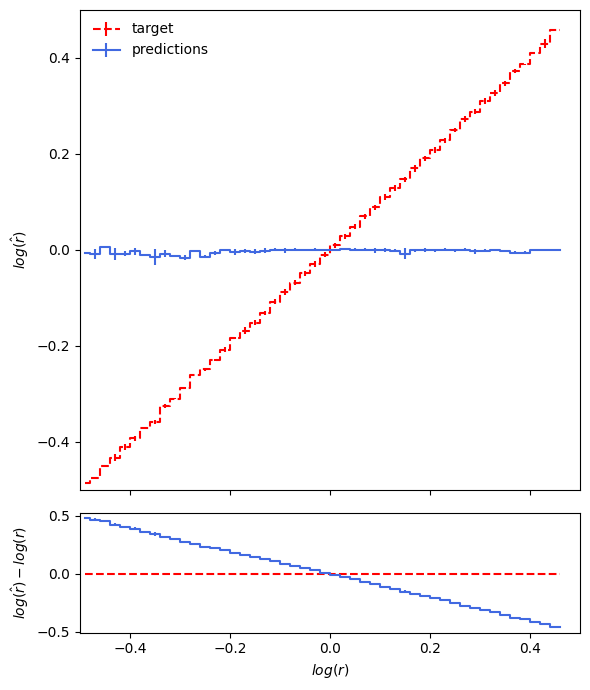

In [155]:
BINS=50

bounds = [-0.5,0.5]

step_size = (bounds[1]-bounds[0])/BINS

p = np.log(ratios_val_pred)
t = np.log(ratios_val_target)

binned_pred = [p[np.where((t>=i*step_size+bounds[0])&(t<(i+1)*step_size+bounds[0]))] for i in range(BINS)]
average_preds = np.array([np.mean(el) for el in binned_pred])
std_dev_preds = np.array([np.std(el) for el in binned_pred])

binned_target = [t[np.where((t>=i*step_size+bounds[0])&(t<(i+1)*step_size+bounds[0]))] for i in range(BINS)]
average_targets = np.array([np.mean(el) for el in binned_target])
std_dev_targets = np.array([np.std(el) for el in binned_target])

centers = [(i+1/2)*step_size+bounds[0] for i in range(BINS)]

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.errorbar(centers, average_targets, yerr=std_dev_targets, drawstyle='steps-mid', color='red', linestyle='--', label='target')
ax1.errorbar(centers, average_preds, yerr=std_dev_preds, drawstyle='steps-mid', color='royalblue', label='predictions')

ax1.set_xlim(*bounds)
ax1.set_ylim(*bounds)
ax1.set_ylabel('$log(\hat{r})$')

ax1.legend(frameon=False)

print(average_preds)
print(average_targets)
print(average_preds/average_targets)

ax2.errorbar(centers, average_targets-average_targets, drawstyle='steps-mid', color='red', linestyle='--', label='target')
ax2.errorbar(centers, average_preds-average_targets, yerr=(std_dev_preds**2 + std_dev_targets**2)**(1/2), drawstyle='steps-mid', color='royalblue', label='predictions')

ax2.set_xlim(*bounds)
ax2.set_xlabel('$log(r)$')
ax2.set_ylabel('$log(\hat{r}) - log(r)$')

plt.tight_layout()

plt.show()

In [156]:
BINS=100

bounds = [-0.5,0.5]

h_calibration_val = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='$r$'),
    hist.axis.Regular(BINS, *bounds, name='$\hat{r}$')
)

h_calibration_val.fill(ratios_val_target, ratios_val_pred)

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_calibration_val.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

plt.show()

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x7f562de40550> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 535x500 with 2 Axes>

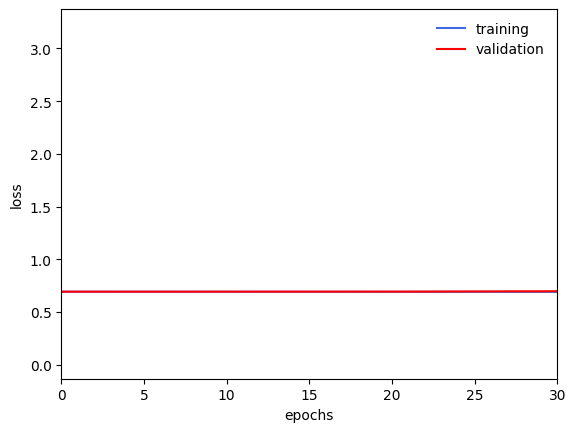

In [168]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs, train_loss, color='royalblue', label='training')
plt.plot(epochs, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')

#plt.ylim(0.6926,0.6932)

plt.legend(frameon=False)

plt.show()